# Assignment 4

Deadline: 22.04.2026 12:00 CET

<Barbero Lorenzo 25-743-709 lorenzo.barbero@uzh.ch>

## Prerequisites: Library imports, data load and initialization of the backtest service

In [76]:
# Standard library imports
import os
import sys
import copy
from typing import Optional
from pathlib import Path


# Third party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


project_root = Path.cwd().resolve().parent  # if notebook is opened from assignments/
# If you sometimes open notebook with CWD elsewhere, use the notebook file path method

src_path = project_root / "src"

sys.path.insert(0, str(src_path))
# Add the project root directory to Python path
project_root = os.path.dirname(os.path.dirname(os.getcwd()))
src_path = os.path.join(project_root, 'qpmwp-course\\src')
sys.path.append(project_root)
sys.path.append(src_path)

# Local modules imports
from helper_functions import (
    # load_pickle,
    load_data_spi,
)
from estimation.covariance import Covariance
from estimation.expected_return import ExpectedReturn
from optimization.constraints import Constraints
from optimization.optimization_data import OptimizationData
from optimization.optimization import (
    Optimization,
    Objective,
    MeanVariance,
)
from backtesting.backtest_item_builder.bib_classes import (
    SelectionItemBuilder,
    OptimizationItemBuilder,
)
from backtesting.backtest_item_builder.bibfn_selection import (
    bibfn_selection_min_volume,
    bibfn_selection_gaps,
)
from backtesting.backtest_item_builder.bibfn_optimization_data import (
    bibfn_return_series,
)
from backtesting.backtest_item_builder.bibfn_constraints import (
    bibfn_budget_constraint,
    bibfn_box_constraints,
    bibfn_size_dependent_upper_bounds,
)
from backtesting.backtest_data import BacktestData
from backtesting.backtest_service import BacktestService
from backtesting.backtest import Backtest



In [77]:

PATH_TO_DATA = "/Users/lorenzobarbero/Library/CloudStorage/OneDrive-Personale/università/ETH UZH/FS26/Quant. Portfolio Management with Python/qpmwp-course/data/"

In [78]:

# Load market and jkp data from parquet files
market_data = pd.read_parquet(path = f'{PATH_TO_DATA}market_data.parquet')
jkp_data = pd.read_parquet(path = f'{PATH_TO_DATA}jkp_data.parquet')


# -------------------------
# First, ensure that market data and jkp data 
# have the same dates by forward filling the market data for the missing dates.
# -------------------------

market_data_dates = (
    market_data
    .index.get_level_values('date')
    .unique().sort_values()
)
jkp_data_dates = (
    jkp_data
    .index.get_level_values('date')
    .unique().sort_values()
)

# Find the jkp_data_dates which are not in the market_data_dates
missing_dates = jkp_data_dates[~jkp_data_dates.isin(market_data_dates)]

# Extend the market data for the missing dates using the last available market data (i.e., forward fill).
tmp_dict = {}
for date in missing_dates:
    last_date = market_data_dates[market_data_dates <= date][-1]
    tmp_dict[date] = market_data.loc[last_date]
    
df_missing = pd.concat(tmp_dict, axis=0)
df_missing.index.names = market_data.index.names
market_data_ffill = pd.concat([market_data, df_missing]).sort_index()


# -------------------------
# Define rebalancing dates
# -------------------------

n_month = 3 # We want to rebalance every n_month months

# We want to use the dates from the jkp data for rebalancing, 
# since they are less frequent than the market data dates.
rebdates = (
    jkp_data_dates[
        jkp_data_dates > market_data_dates[0]
    ][::n_month]
    .strftime('%Y-%m-%d').tolist()
)
# Drop the first rebalancing dates which are before 2002-01-01, 
# because of poor data coverage.
rebdates = [date for date in rebdates if date > '2002-01-01']


# -------------------------
# Instantiate the BacktestData class
# and set the market, jkp, and benchmark data as attributes
# -------------------------

data = BacktestData()
data.market_data = market_data_ffill  # notice that we use the forward filled market data here
data.jkp_data = jkp_data
data.bm_series = load_data_spi(path='../data/')

In [79]:
# Define the selection item builders.
selection_item_builders = {
    'gaps': SelectionItemBuilder(
        bibfn=bibfn_selection_gaps,
        width=365 * 3,
        n_days=10,
    ),
    'min_volume': SelectionItemBuilder(
        bibfn=bibfn_selection_min_volume,
        width=365 * 3,
        min_volume=500_000,
        agg_fn=np.median,
    ),
}

# Define the optimization item builders.
optimization_item_builders = {
    'return_series': OptimizationItemBuilder(
        bibfn=bibfn_return_series,
        width=365 * 3,
        fill_value=0,
    ),
    'budget_constraint': OptimizationItemBuilder(
        bibfn=bibfn_budget_constraint,
        budget=1
    ),
    'box_constraints': OptimizationItemBuilder(
        bibfn=bibfn_box_constraints,
        upper=0.1
    ),
    'size_dep_upper_bounds': OptimizationItemBuilder(
        bibfn = bibfn_size_dependent_upper_bounds,
        small_cap = {'threshold': 300_000_000, 'upper': 0.02},
        mid_cap = {'threshold': 1_000_000_000, 'upper': 0.05},
        large_cap = {'threshold': 10_000_000_000, 'upper': 0.1},
    ),
}

# Initialize the backtest service
bs = BacktestService(
    data=data,
    selection_item_builders=selection_item_builders,
    optimization_item_builders=optimization_item_builders,
    rebdates=rebdates,
)

## 1. Maximum Sharpe Ratio Portfolio

a) 

(6 points)

Complete the `MaxSharpe` class below by implementing its methods `set_objective` and `solve`.
The `solve` method should implement an iterative algorithm that quickly approximates the "true" maximimum Sharpe ratio portfolio (given the estimates of mean and covariance). This approximation should be done by repeatedly solving a mean-variance optimization problem, where the risk aversion parameter (which scales the covariance matrix) is adjusted in each iteration. The algorithm should terminate after a maximum of 10 iterations. 

In [80]:
class MaxSharpe(Optimization):

    def __init__(self,
                 constraints: Optional[Constraints] = None,
                 covariance: Optional[Covariance] = None,
                 expected_return: Optional[ExpectedReturn] = None,
                 **kwargs) -> None:
        super().__init__(
            constraints=constraints,
            **kwargs,
        )
        self.covariance = Covariance() if covariance is None else covariance
        self.expected_return = ExpectedReturn() if expected_return is None else expected_return

    def set_objective(self, optimization_data: OptimizationData) -> None:
        X = optimization_data['return_series']

        # Estimate and store coefficients
        self.mu = self.expected_return.estimate(X=X, inplace=False)
        self.covmat = self.covariance.estimate(X=X, inplace=False)

        # Risk-free rate
        rf = self.params.get('risk_free_rate', 0.0)

        # Excess expected returns
        self.mu_excess = self.mu - rf

        risk_aversion = self.params.get('risk_aversion', 1.0)

        self.objective = Objective(
            q = self.mu_excess * (-1),
            P = self.covmat * 2 * risk_aversion,
            )
        
        return None

    def solve(self) -> None:
        max_iter = 10
        tol = 1e-8

        # Initial guess for risk aversion
        risk_aversion = self.params.get('risk_aversion', 1.0)

        best_results = None
        best_sharpe = -np.inf

        for _ in range(max_iter):

            # Update lambda in params
            self.params['risk_aversion'] = risk_aversion

            # Update objective with current lambda
            self.objective = Objective(
                q = self.mu_excess * (-1),
                P = self.covmat * 2 * risk_aversion,
                )
            # Solve the quadratic problem
            super().solve()

            # Extract weights
            w = pd.Series(self.results['weights']).reindex(self.constraints.ids).astype(float)
            w = w.to_numpy()

            # Portfolio mean and variance
            mu_p_excess = float(np.dot(self.mu_excess, w))
            var_p = float(w.T @ self.covmat @ w)

            if var_p <= 0:
                break

            sharpe = mu_p_excess / np.sqrt(var_p)

            # Store best solution
            if sharpe > best_sharpe:
                best_sharpe = sharpe
                best_results = self.results.copy()
                best_results['sharpe'] = sharpe
                best_results['risk_aversion'] = risk_aversion

            # Fixed-point update
            new_risk_aversion = mu_p_excess  / (2 * var_p)

            # Stop if converged
            if abs(new_risk_aversion - risk_aversion) < tol:
                best_results['sharpe'] = sharpe
                best_results['risk_aversion'] = risk_aversion
                self.results = best_results
                return None

            risk_aversion = new_risk_aversion

        # Fallback: return best iterate found
        if best_results is not None:
            self.results = best_results
        return None
    

b) 

(2 points)

Provide either a theoretical or an empirical justification that your algorithm converges to the true maximum Sharpe ratio portfolio for the given coefficients of mean and covariance.
Hint: If you want to provide an empirical justification, you can perform an optimization for a single point in time by running the following code.

### Theoretical Justification
The Max Sharpe Problem is not a Quadratic Problem. Indeed is given by:
$$
\max_{w} \frac{(\mu - r_f 1)^Tw}{\sqrt{w^T\Sigma w}}
$$

Therefore, in order to obtain a mean-variance problem, some changes must be done:
We can notice that the problem does not depend on the size of the weights, which can be standardized. Indeed:

$$
\max_{w} \frac{(\mu - r_f 1)^Tw}{\sqrt{w^T\Sigma w}} =\max_{w} \frac{c(\mu - r_f 1)^Tw}{\sqrt{c^2 w^T\Sigma w}}
$$
So we can set:
$$
y = \frac{w}{(\mu - r_f 1)^Tw}\Rightarrow (\mu - r_f 1)^Ty = 1
$$
After this change, This transforms the problem into an equivalent variance-minimization problem with a linear equality constraint.
The Optimization problem becomes either:
$$
\min_w y^T\Sigma y \,\,\,\,s.t.\,\,\, (\mu - r_f 1)^Ty = 1
$$ 
or 
$$
\max_w (\mu - r_f 1)^Ty \,\,\,\,s.t.\,\,\, \Sigma = \hat{\sigma}
$$
which is a QP. Now we can apply the Lagrangian:
$$
\mathcal{L} = y^T\Sigma y-\lambda((\mu - r_f 1)^Ty-1)
$$
So the FOCs are:
$$
2\Sigma y = \lambda(\mu - r_f 1) \Rightarrow y^* = \frac{\lambda}{2}\Sigma^{-1}(\mu - r_f 1)
$$
So the Max Sharpe Ratio weights are given by $ y^* $ and they can be normalized as:
$$
w^{MS} = \frac{\Sigma^{-1}(\mu - r_f 1)}{1^T\Sigma^{-1}(\mu - r_f 1)}
$$
But since we have stated that they do not depend on the size, but only by the direction, what matters is that weights are proportional to $\Sigma^{-1}(\mu - r_f 1)$.

Now consider the mean-variance problem that we used in the implementation:
$$
\min_w -(\mu - r_f 1)w + \gamma w^T\Sigma w
$$
Its FOC is:
$$
-(\mu - r_f 1) + 2\gamma \Sigma w = 0 \Rightarrow w^{*} = \frac{1}{2\gamma}\Sigma^{-1}(\mu - r_f 1)
$$
Which is exaclty proprtional to the $y^*$ described above.

In [81]:
bs.optimization = MaxSharpe(
    covariance=Covariance(method='pearson'),
    expected_return=ExpectedReturn(method='geometric'),
    solver_name='cvxopt',  # <change this to your preferred solver>
    # <optionally add any other arguments you may need, e.g., number of iterations, tolerance, etc.>
)
bs.prepare_rebalancing(rebdates[-1])
bs.optimization.set_objective(bs.optimization_data)
bs.optimization.solve()

bs.optimization.results


{'weights': {'102': 6.661181837026534e-07,
  '103': 3.199372409041939e-07,
  '104': 5.506240813662332e-07,
  '111': 1.535212661749043e-05,
  '120': 0.04999934301911663,
  '122': 1.4233355346076266e-06,
  '125': 1.7860803422262262e-07,
  '126': 2.195452402145643e-06,
  '127': 0.09997942419651455,
  '128': 3.1529284241742157e-06,
  '129': 0.09997718803695305,
  '134': 4.6168549895415014e-07,
  '136': 2.6145010942672224e-06,
  '139': 1.1211833925479785e-06,
  '141': 3.5536856155249885e-07,
  '142': 2.4821937309735853e-07,
  '148': 4.294027157225797e-07,
  '149': 6.6252030807739576e-06,
  '154': 0.09999756357551541,
  '159': 6.197342876248838e-07,
  '161': 6.544249628622281e-07,
  '169': 6.248253226792783e-07,
  '170': 0.0181918582462144,
  '174': 3.6135672006039664e-07,
  '175': 2.665798936078776e-07,
  '176': 2.6455240874201343e-07,
  '177': 0.019175766196484603,
  '184': 6.816498467189993e-07,
  '185': 1.2843181944302888e-06,
  '191': 4.163900162323345e-07,
  '192': 0.013621261375760836

## 2. Backtest MaxSharpe with Turnover Penalty

(5 points)

The code below runs a backtest of a MaxSharpe portfolio that includes a turnover penalty. The optimization problem is

$$
\arg\min_{w}\;\Bigl(-\mu^\top w \;+\; \frac{\lambda}{2}\, w^\top \Sigma w \;+\; \tau |w - w^{0}|\Bigr),
$$

where $\mu$ is the vector of expected returns, $\Sigma$ the covariance matrix, and $w^{0}$ the initial portfolio weights.
The parameter $\lambda$ is the risk‑aversion coefficient calibrated in Question 1.a, and $\tau$ is the turnover penalty parameter to be calibrated here.

Your task is to choose a value for the turnover penalty such that the MaxSharpe backtest exhibits an annual turnover of approximately 100\%.

**Hint:** run the backtest for only a few rebalancing dates, compute the resulting turnover using method `bt_ms.turnover`, and iteratively adjust the turnover penalty until the target turnover is reached.


In [82]:
# Update the backtest service with a MaxSharpe optimization object
bs.optimization = MaxSharpe(
    covariance=Covariance(method='pearson'),
    expected_return=ExpectedReturn(method='geometric'),
    solver_name='cvxopt',     # optionally, change this to your preferred solver
    turnover_penalty=0.00011,    # <your code here>
)

# Instantiate the backtest object
bt_ms = Backtest()

# Run the backtest
bt_ms.run(bs=bs)

Rebalancing date: 2002-01-31
Rebalancing date: 2002-04-30
Rebalancing date: 2002-07-31
Rebalancing date: 2002-10-31
Rebalancing date: 2003-01-31
Rebalancing date: 2003-04-30
Rebalancing date: 2003-07-31
Rebalancing date: 2003-10-31
Rebalancing date: 2004-01-31
Rebalancing date: 2004-04-30
Rebalancing date: 2004-07-31
Rebalancing date: 2004-10-31
Rebalancing date: 2005-01-31
Rebalancing date: 2005-04-30
Rebalancing date: 2005-07-31
Rebalancing date: 2005-10-31
Rebalancing date: 2006-01-31
Rebalancing date: 2006-04-30
Rebalancing date: 2006-07-31
Rebalancing date: 2006-10-31
Rebalancing date: 2007-01-31
Rebalancing date: 2007-04-30
Rebalancing date: 2007-07-31
Rebalancing date: 2007-10-31
Rebalancing date: 2008-01-31
Rebalancing date: 2008-04-30
Rebalancing date: 2008-07-31
Rebalancing date: 2008-10-31
Rebalancing date: 2009-01-31
Rebalancing date: 2009-04-30
Rebalancing date: 2009-07-31
Rebalancing date: 2009-10-31
Rebalancing date: 2010-01-31
Rebalancing date: 2010-04-30
Rebalancing da

In [83]:
X = bs.data.get_return_series(
    end_date=bs.settings['rebdates'][-1],
    fillna_value=0
)

to = bt_ms.strategy.turnover(return_series=X).iloc[1:]

annual_turnover = 4 * to.mean()

print("Annual turnover:", annual_turnover)

Annual turnover: 0.99105884937922


## 4. Simulation and Descriptive Statistics

(3 points)

- Simulate the portfolio returns from your MaxSharpe backtest. Use fixed costs of 1% per annum (p.a.) and variable costs of 0.3% p.a.
- Plot the cumulated returns of the MaxSharpe strategy together with those of the SPI Index.
- Plot the turnover of your MaxSharpe strategy over time.
- Print the annualized turnover (computed as the average turnover over the backtest multiplied by the number of rebalancing per year) for your MaxSharpe strategy.
- Create and print a table with descriptive performance statistics for your MaxSharpe strategy and the SPI Index.


/Users/lorenzobarbero/Library/CloudStorage/OneDrive-Personale/università/ETH UZH/FS26/Quant. Portfolio Management with Python/qpmwp-course/src/backtesting/strategy.py:195: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  portf_ret[0] -= varcost[0]
/Users/lorenzobarbero/Library/CloudStorage/OneDrive-Personale/università/ETH UZH/FS26/Quant. Portfolio Management with Python/qpmwp-course/src/backtesting/strategy.py:195: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  portf_ret[0] -= varcost[0]


<Axes: title={'center': 'Cumulative Returns'}>

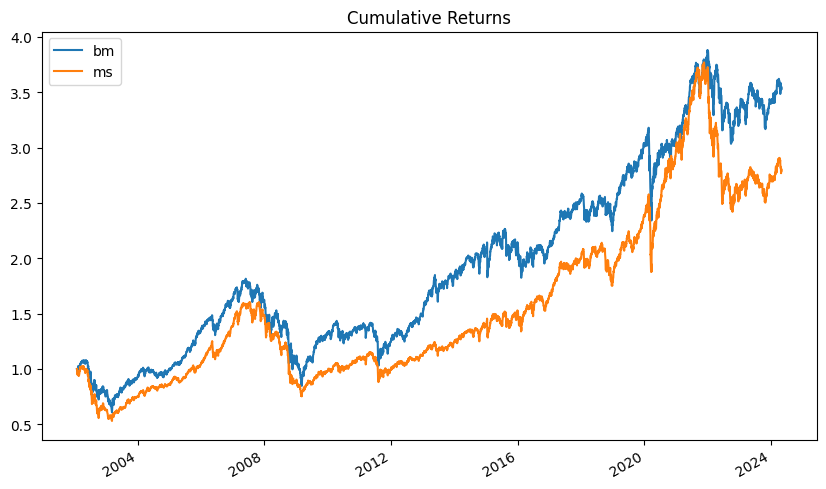

In [84]:
fixed_costs = 0.01 # <your code here> 
variable_costs = 0.003 # <your code here>
return_series = bs.data.get_return_series(weekdays_only=False)

sim_ms = bt_ms.strategy.simulate(
    return_series=return_series,
    fc=fixed_costs,
    vc=variable_costs
)

sim = pd.concat({
    'bm': bs.data.bm_series,
    'ms': sim_ms,
}, axis = 1).dropna()

# Plot the cumulative returns of the strategy and the benchmark
# <your code here>
(1 + sim).cumprod().plot(figsize=(10,6), title="Cumulative Returns")


<Axes: title={'center': 'Turnover'}>

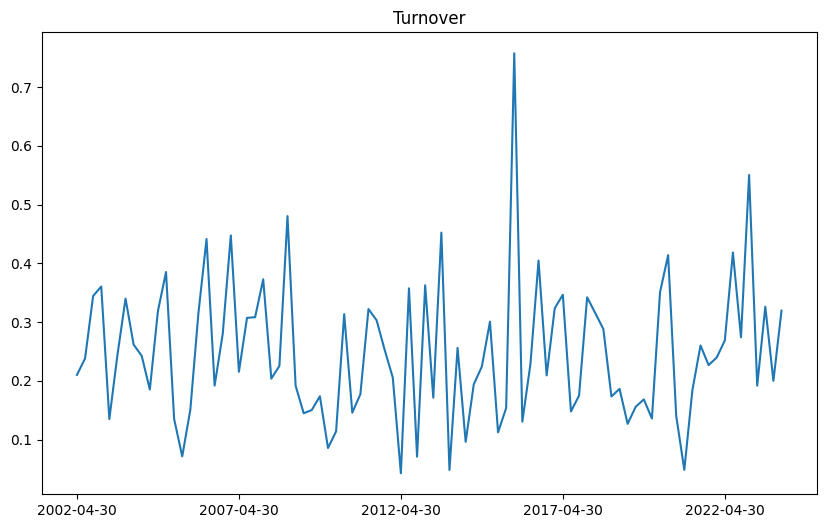

In [85]:
# Turnover
to_ms = bt_ms.strategy.turnover(return_series=return_series)
to_ms.iloc[1:].plot(title='Turnover', figsize = (10, 6))


In [86]:

# Annualized turnover per annum (pa) in percentage
to_pa = 4 * to_ms.iloc[1:].mean() * 100
print(f"The annualized turnover is: {to_pa}%")

The annualized turnover is: 99.41318854765228%


In [87]:
# Decriptive statistics
print("Descriptive statistics of the strategy returns:")
print(sim_ms.describe())

Descriptive statistics of the strategy returns:
count    5873.000000
mean        0.000216
std         0.009079
min        -0.080086
25%        -0.003645
50%         0.000354
75%         0.004910
max         0.078533
dtype: float64


In [88]:
# Decriptive statistics

stats = pd.DataFrame({
    'Mean': sim.mean(),
    'Volatility': sim.std(),
    'Sharpe': (sim.mean() / sim.std()),
    'Min': sim.min(),
    '25%': sim.quantile(0.25),
    'Median': sim.median(),
    '75%': sim.quantile(0.75),
    'Max': sim.max()
})

print(stats)

        Mean  Volatility    Sharpe       Min       25%    Median       75%  \
bm  0.000269    0.010372  0.025913 -0.091109 -0.004282  0.000262  0.005273   
ms  0.000216    0.009079  0.023802 -0.080086 -0.003645  0.000354  0.004910   

         Max  
bm  0.105788  
ms  0.078533  
